<a href="https://colab.research.google.com/github/ariyanabonab/diffusion-ic/blob/training-practice/notebooks/01-Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Installing JaxPM
!pip install --quiet --upgrade jax
!pip install --quiet jaxpm
# CPU-only for a clean first run alongside JAX.
!pip -q install torch score_models h5py tqdm
!pip install score_models
import os
os.environ["JAX_PLATFORMS"] = "cpu"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 MB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.0 MB/s eta 0:00:00


In [3]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc

from jax.experimental.ode import odeint

from jaxpm.painting import cic_paint
from jaxpm.pm import linear_field, lpt, make_ode_fn

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.3 is installed, but it is not compatible with the installed jaxlib version 0.7.2, so it will not be used.
  warnings.warn(


In [37]:
import numpy as np

mesh_shape = [32, 32, 32]
box_size = [32., 32., 32.]
snapshots = jnp.array([0.1, 0.5, 1.0])

@jax.jit
def run_simulation(omega_c, sigma8):
    # Create a small function to generate the matter power spectrum
    k = jnp.logspace(-4, 1, 128)
    pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)


# for i in range[_]
# initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(_))




    # Create initial conditions and particles
    initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(2)) # change this 0 or 1 to another number each time i run it
    particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

    # Initial displacement
    cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)
    dx, p, f = lpt(cosmo, initial_conditions, particles, a=0.1)

    # Evolve the simulation forward
    res = odeint(make_ode_fn(mesh_shape), [particles + dx, p], snapshots, cosmo, rtol=1e-8, atol=1e-8)

    # Return the simulation volume at requested timesteps
    return initial_conditions ,  particles + dx , res[0]

initial_conditions[None,...]
ic = initial_conditions[None,...]
ic.shape
np.save('ic_' + '[i]' + '.npy')


# Create a NumPy array
arr = np.array([1, 2, 3, 4, 5])

# Save the array to a file named 'my_array.npy'
np.save('my_array.npy', arr)

print(ic)

In [ ]:
# in this cell save each ic and fd as ic_0.npy
# using np.save

In [30]:
final_density = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , field)+1)

In [31]:
#fd = final_density[None,...] # numpy trick that allows for 1,N,N,N shape
#fd.shape

initial_conditions[None,...]
ic = initial_conditions[None,...]
ic.shape

# save np.save for ic and fd to put into getitem

# after this line can save fd and ic to disk save as 0.ic.npy, 0.fd.npy, each time i save

# make a for loop to then save each, or i can manually change it from 0 to 100 each time
# np.save for both

(1, 32, 32, 32)

In [32]:
# initial_conditions vs ic , ic has 4 brackets vs initial_conditions has 3 brackets to account for shape 1, N, N, N
# reload each with getiem to load each in disk
# how to change each ic so its different each time


In [42]:
import torch
from torch.utils.data import TensorDataset
from score_models import ScoreModel, EnergyModel, MLP, NCSNpp
import shutil, os
import numpy as np

# can tweak dimensions, nf, ch_mult, sigma_min, sigma_max, epochs, batch_size, learning_rate, and steps

dimensions = 3
nf = 128
sigma_min = 1e-3
sigma_max = 1e2
epochs = 1
batch_size = 1
learning_rate = 1e-4
steps = 100

class Dataset(torch.utils.data.Dataset):
    def __init__(self):
      pass

    def __len__(initial_conditions):
        return initial_conditions.size

   # def __getitem__(self, i): # i know i want to put my IC, FD input here into getitem and index = final_density
      # go to file location, go to wherever you saved on disk to then load here
      # return ic and fd both which i loaded from file
      # to check if works, use dataset = Dataset()
      # then try print(dataset[i]) and this should print ic and fd
      # if this does not give error then it is done correctly

SyntaxError: incomplete input (ipython-input-843387142.py, line 30)

In [39]:
initial_conditions , lpt_particles , ode_particles = run_simulation(0.25, 0.8)

In [40]:
from score_models import ScoreModel, EnergyModel, NCSNpp, MLP, DDPM
from torch.utils.data import Dataset # Import Dataset
import torch # Import torch

# B is the batch size
# C is the input channels
# dimensions are the spatial dimensions (e.g. [28, 28] for MNIST)

# Create a ScoreModel instance with Yang Song's NCSN++ architecture and the VESDE
#net = NCSNpp(channels=C, dimensions=len(dimensions), nf=128, ch_mult=[2, 2, 2, 2])
#model = ScoreModel(model=net, sigma_min=1e-3, sigma_max=40, device="cpu")
# ... or the VPSDE

# NN Architectures support a Unet with 1D convolutions for time series input data
#net = NCSNpp(channels=C, nf=128, ch_mult=[2, 2, 2, 2], dimensions=2)
# ... or 3D convolutions for videos/voxels
##net = NCSNpp(channels=1, nf=128, ch_mult=[2, 2, 2, 2], attention=False, dimensions=3)
# You can also use a simpler MLP architecture (dimensions=0)
#net = MLP(dimensions=C, layers=4, units=100)
# ... or Jonathan Ho's DDPM architecture
net = DDPM(channels=1, nf=128, ch_mult=[2, 2, 2, 2])
model = ScoreModel(model=net, beta_min=1e-3, beta_max=40, device="cpu")

# Define B, C, and dimensions (using values from the test_training_conditioned_input_ncsnpp function as an example)
B = 3
C = 1
dimensions = [32, 32] # Assuming 2D data based on the commented out NCSNpp example

# Train the score model, and save its weight in checkpoints_directory
#model.fit(dataset, epochs=100, batch_size=B, learning_rate=1e-4, checkpoints_directory=checkpoints_directory)

# Generate samples from the trained model (steps is the number of Euler-Maruyama steps)
samples = model.sample(shape=[B, C, *dimensions], steps=100) # Added C to shape

# Compute the score for a given input
# Need to define 't' and 'x' before calling model.score(t, x)
# score = model.score(t, x)

# Initialise the score model and its neural network from a path to a checkpoint directory
# Need to define 'checkpoints_directory' before calling ScoreModel(checkpoints_directory=checkpoints_directory)
# model = ScoreModel(checkpoints_directory=checkpoints_directory)

# TO DO: run 100 sims to output IC & FD in shape (1,N,N,N)

Using the Variance Preserving SDE


Sampling from the prior | t = 0.0 | sigma = 4.5e-02| scale ~ 1.6e+04: 100%|██████████| 100/100 [01:23<00:00,  1.20it/s]


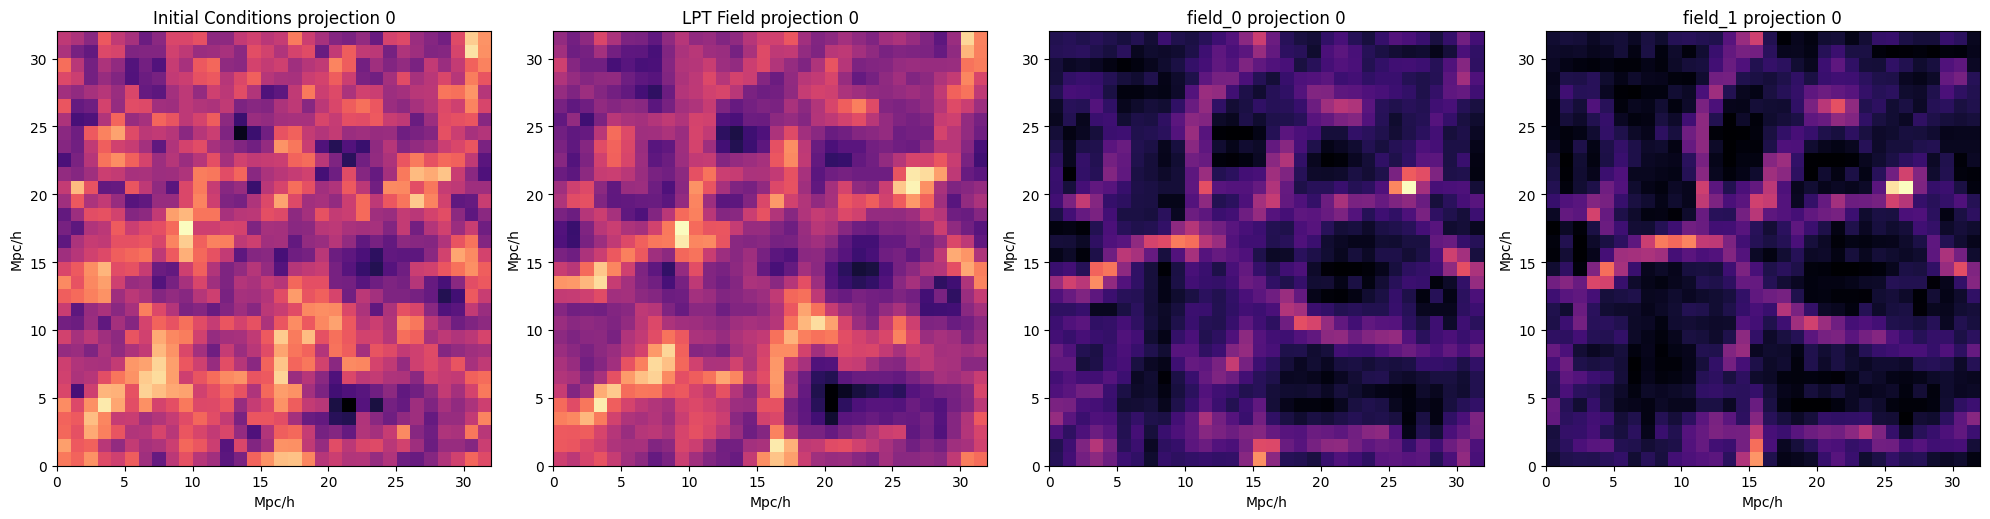

In [41]:
from jaxpm.plotting import plot_fields_single_projection

fields = {"Initial Conditions" : initial_conditions , "LPT Field" : jnp.log10(cic_paint(jnp.zeros(mesh_shape) ,lpt_particles) + 1)}
for i , field in enumerate(ode_particles[1:]):
    fields[f"field_{i}"] = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , field)+1)
plot_fields_single_projection(fields)